# Incremental Capstone - Aamir Mohammed

## Task 1: Feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('FloridaBikeRentals.csv')
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,01-12-2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01-12-2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01-12-2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01-12-2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01-12-2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [2]:
df.describe()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   object 
 1   Rented Bike Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew point temperature  8760 non-null   float64
 8   Solar Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   object 
 12  Holiday                8760 non-null   object 
 13  Functioning Day        8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.3+ 

In [4]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature,0
Humidity,0
Wind speed,0
Visibility,0
Dew point temperature,0
Solar Radiation,0
Rainfall,0


In [5]:
df.dtypes

,0
Date,object
Rented Bike Count,int64
Hour,int64
Temperature,float64
Humidity,int64
Wind speed,float64
Visibility,int64
Dew point temperature,float64
Solar Radiation,float64
Rainfall,float64


In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Seasons'] = df['Seasons'].astype('category')
df['Holiday'] = df['Holiday'].astype('category')
df['Functioning Day'] = df['Functioning Day'].astype('category')

df['Temperature'] = df['Temperature'].astype('float')
df['Humidity'] = pd.to_numeric(df['Humidity'], downcast='integer')
df['Wind speed'] = df['Wind speed'].astype('float')
df['Hour'] = pd.to_numeric(df['Hour'], downcast='integer')
df['Rented Bike Count'] = pd.to_numeric(df['Rented Bike Count'], downcast='integer')

In [7]:
# Creating Interaction Features

df['Temp-Humidity'] = df['Temperature'] * df['Humidity']
df['Hour-Temp'] = df['Temperature'] * df['Hour']
df['Hour-Humidity'] = df['Humidity'] * df['Hour']

In [8]:
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Temp-Humidity,Hour-Temp,Hour-Humidity
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-192.4,-0.0,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-209.0,-5.5,38
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,-234.0,-12.0,78
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-248.0,-18.6,120
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-216.0,-24.0,-112


In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
cols = ['Seasons', 'Holiday', 'Functioning Day']


for col in cols:
    df[col] = le.fit_transform(df[col])

In [10]:
df[['Seasons', 'Holiday', 'Functioning Day']]

,Seasons,Holiday,Functioning Day
0,3,1,1
1,3,1,1
2,3,1,1
3,3,1,1
4,3,1,1
...,...,...,...
8755,0,1,1
8756,0,1,1
8757,0,1,1
8758,0,1,1


In [11]:
# Scale the numerical features using StandardScaler

numcols =['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility',
    'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall',
    'Temp-Humidity', 'Hour-Temp', 'Hour-Humidity'
    ]
scaler = StandardScaler()
df[numcols] = scaler.fit_transform(df[numcols])

In [12]:
df.to_csv('bike_rental_features.csv', index=False)
print("Processed Data Saved")

Processed Data Saved


## ----------------------------------------------------------------------------------------------

# Part 2

## Model building

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = df.drop(columns=['Rented Bike Count', 'Date'])
y = df['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7008, 15)
X_test shape: (1752, 15)
y_train shape: (7008,)
y_test shape: (1752,)


In [15]:
# Linear Regression
linear = LinearRegression()
linear.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = linear.predict(X_test)
x_pred = linear.predict(X_train)

print("r2 Training Score:", r2_score(y_train, x_pred))
print("r2 Testing Score:", r2_score(y_test, y_pred))

r2 Training Score: 0.5995591078106716
r2 Testing Score: 0.5803599733569098


In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression:")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Linear Regression:
Mean Absolute Error: 294.8098680932525
Mean Squared Error: 174841.43829271203
R-squared: 0.5803599733569098


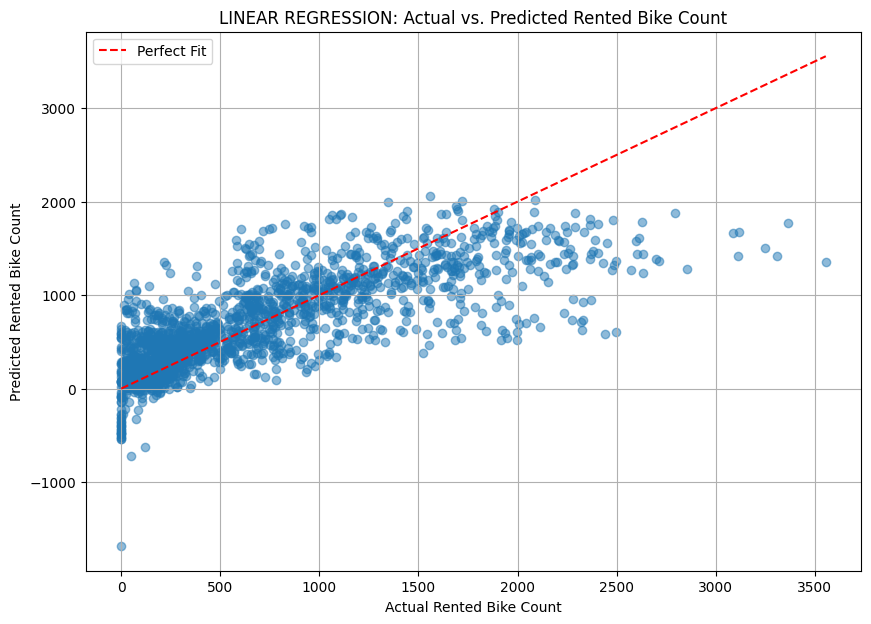

In [18]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("LINEAR REGRESSION: Actual vs. Predicted Rented Bike Count")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Ridge Regression
from sklearn.linear_model import Ridge, RidgeCV

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [20]:
y_pred_r = ridge.predict(X_test)
x_pred_r = ridge.predict(X_train)

print("r2 Training Score Ridge:", r2_score(y_train, x_pred_r))
print("r2 Testing Score Ridge:", r2_score(y_test, y_pred_r))

r2 Training Score Ridge: 0.5995573969949822
r2 Testing Score Ridge: 0.5803819672251634


In [21]:
mae_r = mean_absolute_error(y_test, y_pred_r)
mse_r = mean_squared_error(y_test, y_pred_r)
r2_r = r2_score(y_test, y_pred_r)

print("Ridge Regression:")
print("Mean Absolute Error:", mae_r)
print("Mean Squared Error:", mse_r)
print("R-squared:", r2_r)

Ridge Regression:
Mean Absolute Error: 294.7837896238478
Mean Squared Error: 174832.27463025154
R-squared: 0.5803819672251634


In [22]:
# Now we get the best alpha (regularization strength) selected by cross-validation
np.random.seed(42)
ridge_cv = RidgeCV(alphas=np.random.randint(0, 200, 15), cv=10)
ridge_cv.fit(X_train, y_train)

RidgeCV(alphas=array([102, 179,  92,  14, 106,  71, 188,  20, 102, 121,  74,  87, 116,
        99, 103]),
        cv=10)

In [23]:
ridge_cv.alpha_

np.int64(14)

In [24]:
ridge_tuned = Ridge(alpha=ridge_cv.alpha_, max_iter=1000)
ridge_tuned.fit(X_train, y_train)

Ridge(alpha=np.int64(14), max_iter=1000)

In [25]:
y_pred_rt = ridge_tuned.predict(X_test)
x_pred_rt = ridge_tuned.predict(X_train)

print("r2 Training Score Ridge Tuned:", r2_score(y_train, x_pred_rt))
print("r2 Testing Score Ridge Tuned:", r2_score(y_test, y_pred_rt))

r2 Training Score Ridge Tuned: 0.5992778426782657
r2 Testing Score Ridge Tuned: 0.5804190898375311


In [26]:
mae_rt = mean_absolute_error(y_test, y_pred_rt)
mse_rt = mean_squared_error(y_test, y_pred_rt)
r2_rt = r2_score(y_test, y_pred_rt)

print("Ridge Regression Tuned:")
print("Mean Absolute Error:", mae_rt)
print("Mean Squared Error:", mse_rt)
print("R-squared:", r2_rt)

Ridge Regression Tuned:
Mean Absolute Error: 294.4891218261509
Mean Squared Error: 174816.80763347464
R-squared: 0.5804190898375311


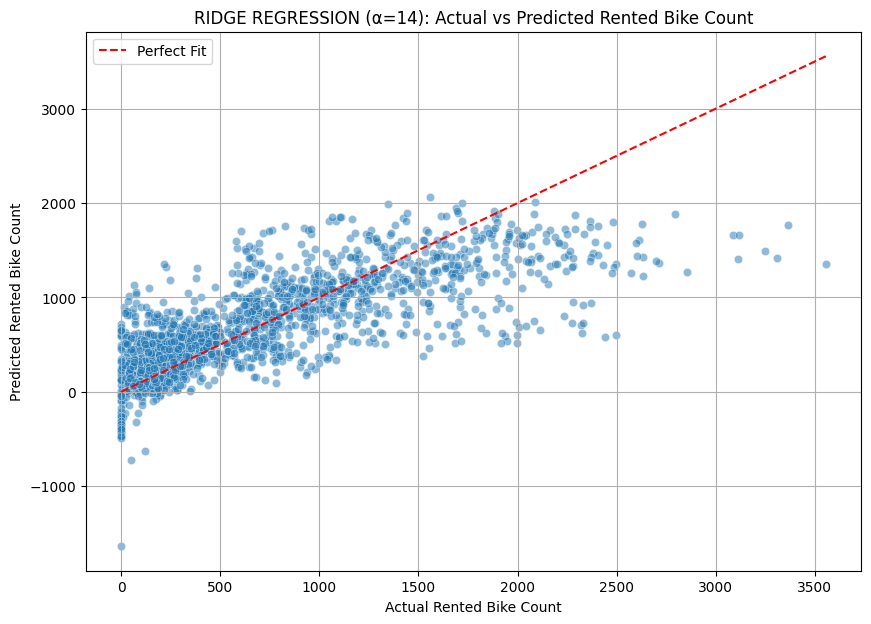

In [27]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=y_test, y=y_pred_rt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title(f"RIDGE REGRESSION (α={ridge_cv.alpha_}): Actual vs Predicted Rented Bike Count")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Now Lasso Regression
from sklearn.linear_model import Lasso, LassoCV

lasso = Lasso(alpha=1.0, max_iter=1000, random_state=42)
lasso.fit(X_train, y_train)

Lasso(random_state=42)

In [29]:
y_pred_l = lasso.predict(X_test)
x_pred_l = lasso.predict(X_train)

print("r2 Training Score Lasso:", r2_score(y_train, x_pred_l))
print("r2 Testing Score Lasso:", r2_score(y_test, y_pred_l))

r2 Training Score Lasso: 0.5991922571106179
r2 Testing Score Lasso: 0.5796925933501573


In [30]:
mae_l = mean_absolute_error(y_test, y_pred_l)
mse_l = mean_squared_error(y_test, y_pred_l)
r2_l = r2_score(y_test, y_pred_l)

print("Lasso Regression:")
print("Mean Absolute Error:", mae_l)
print("Mean Squared Error:", mse_l)
print("R-squared:", r2_l)

Lasso Regression:
Mean Absolute Error: 295.157495851346
Mean Squared Error: 175119.4996616473
R-squared: 0.5796925933501573


In [31]:
# hyperparameter tuning using GridSearchCV

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=42)

grid = dict()
grid['alpha'] = np.logspace(-3, 1, 40)

lasso = Lasso(max_iter=2000, random_state=42)
search = GridSearchCV(lasso, grid, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
results = search.fit(X_train, y_train)

In [32]:
results.best_params_.get('alpha')

np.float64(0.043754793750741844)

In [33]:
lasso_after_gcv = Lasso(alpha=results.best_params_.get('alpha'), max_iter=2000, random_state=42)
lasso_after_gcv.fit(X_train, y_train)

Lasso(alpha=np.float64(0.043754793750741844), max_iter=2000, random_state=42)

In [34]:
y_pred_la = lasso_after_gcv.predict(X_test)
x_pred_la = lasso_after_gcv.predict(X_train)

print("r2 Training Score Lasso After GCV:", r2_score(y_train, x_pred_la))
print("r2 Testing Score Lasso After GCV:", r2_score(y_test, y_pred_la))

r2 Training Score Lasso After GCV: 0.5995584009996351
r2 Testing Score Lasso After GCV: 0.5803450672805497


In [35]:
mae_la = mean_absolute_error(y_test, y_pred_la)
mse_la = mean_squared_error(y_test, y_pred_la)
r2_la = r2_score(y_test, y_pred_la)

print("Lasso Regression After GridSearchCV:")
print("Mean Absolute Error:", mae_la)
print("Mean Squared Error:", mse_la)
print("R-squared:", r2_la)

Lasso Regression After GridSearchCV:
Mean Absolute Error: 294.8147487322373
Mean Squared Error: 174847.6488533465
R-squared: 0.5803450672805497


In [36]:
# now Do Elastic Net Regression
from sklearn.linear_model import ElasticNetCV, ElasticNet

elastic = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=1000, random_state=42)
elastic.fit(X_train, y_train)

ElasticNet(random_state=42)

In [37]:
y_pred_e = elastic.predict(X_test)
x_pred_e = elastic.predict(X_train)

print("r2 Training Score ElasticNet:", r2_score(y_train, x_pred_e))
print("r2 Testing Score ElasticNet:", r2_score(y_test, y_pred_e))

r2 Training Score ElasticNet: 0.5014773318966173
r2 Testing Score ElasticNet: 0.4925054390027491


In [38]:
mae_e = mean_absolute_error(y_test, y_pred_e)
mse_e = mean_squared_error(y_test, y_pred_e)
r2_e = r2_score(y_test, y_pred_e)

print("ElasticNet Regression:")
print("Mean Absolute Error:", mae_e)
print("Mean Squared Error:", mse_e)
print("R-squared:", r2_e)

ElasticNet Regression:
Mean Absolute Error: 324.0430927189445
Mean Squared Error: 211445.69949699982
R-squared: 0.4925054390027491


In [39]:
# Now do ElasticNetCV
alphas = np.logspace(-2, 2, 100)
l1_ratios = np.linspace(0.01, 1, 100)
elastic_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=10, random_state=42)
elastic_cv.fit(X_train, y_train)

ElasticNetCV(alphas=array([1.00000000e-02, 1.09749877e-02, 1.20450354e-02, 1.32194115e-02,
       1.45082878e-02, 1.59228279e-02, 1.74752840e-02, 1.91791026e-02,
       2.10490414e-02, 2.31012970e-02, 2.53536449e-02, 2.78255940e-02,
       3.05385551e-02, 3.35160265e-02, 3.67837977e-02, 4.03701726e-02,
       4.43062146e-02, 4.86260158e-02, 5.33669923e-02, 5.85702082e-02,
       6.42807312e-02, 7.054802...
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ]),
             random_state=42)

In [40]:
elastic_cv.alpha_

np.float64(0.01)

In [41]:
elastic_cv.l1_ratio_


np.float64(0.9500000000000001)

In [42]:
y_pred_ecv = elastic_cv.predict(X_test)
x_pred_ecv = elastic_cv.predict(X_train)

print("r2 Training Score ElasticNetCV:", r2_score(y_train, x_pred_ecv))
print("r2 Testing Score ElasticNetCV:", r2_score(y_test, y_pred_ecv))

r2 Training Score ElasticNetCV: 0.5995377396342625
r2 Testing Score ElasticNetCV: 0.5804195535962726


In [43]:
mae_ecv = mean_absolute_error(y_test, y_pred_ecv)
mse_ecv = mean_squared_error(y_test, y_pred_ecv)
r2_ecv = r2_score(y_test, y_pred_ecv)

print("ElasticNetCV Regression:")
print("Mean Absolute Error:", mae_ecv)
print("Mean Squared Error:", mse_ecv)
print("R-squared:", r2_ecv)

ElasticNetCV Regression:
Mean Absolute Error: 294.7217254865456
Mean Squared Error: 174816.6144101398
R-squared: 0.5804195535962726


## ----------------------------------------------------------------------------------------------

#Part 3 - Model building with polynomial features

In [44]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[numcols])

In [45]:
poly_cols = poly.get_feature_names_out(numcols)

In [46]:
df_poly = pd.DataFrame(X_poly, columns=poly_cols)
df_poly = pd.concat([df.drop(columns=numcols), df_poly], axis=1)
df_poly.head()

,Date,Rented Bike Count,Seasons,Holiday,Functioning Day,Hour,Temperature,Humidity,Wind speed,Visibility,...,Snowfall^2,Snowfall Temp-Humidity,Snowfall Hour-Temp,Snowfall Hour-Humidity,Temp-Humidity^2,Temp-Humidity Hour-Temp,Temp-Humidity Hour-Humidity,Hour-Temp^2,Hour-Temp Hour-Humidity,Hour-Humidity^2
0,2017-12-01,254,3,1,1,-1.661325,-1.513957,-1.042483,0.458476,0.925871,...,0.029547,0.225744,0.144679,-0.001141,1.724747,1.105387,-0.008721,0.708440,-0.005590,0.000044
1,2017-12-01,204,3,1,1,-1.516862,-1.539074,-0.993370,-0.892561,0.925871,...,0.029547,0.229563,0.149702,-0.091142,1.783594,1.163113,-0.708130,0.758487,-0.461784,0.281145
2,2017-12-01,173,3,1,1,-1.372399,-1.580936,-0.944257,-0.699556,0.925871,...,0.029547,0.235314,0.155638,-0.185879,1.874083,1.239531,-1.480376,0.819835,-0.979131,1.169379
3,2017-12-01,107,3,1,1,-1.227936,-1.597680,-0.895144,-0.796059,0.925871,...,0.029547,0.238535,0.161666,-0.285354,1.925734,1.305159,-2.303711,0.884567,-1.561332,2.755877
4,2017-12-01,78,3,1,1,-1.083473,-1.580936,-1.091596,0.554978,0.925871,...,0.029547,0.231173,0.166598,0.264123,1.808705,1.303466,2.066507,0.939359,1.489254,2.361054


In [47]:
print(df_poly.shape)
print(df.shape)

(8760, 95)
(8760, 17)


In [48]:
# Perform train test split

X_poly = df_poly.drop(columns=['Rented Bike Count', 'Date'])
y_poly = df_poly['Rented Bike Count']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

In [49]:
print("X_train_p shape:", X_train_p.shape)
print("X_test_p shape:", X_test_p.shape)

X_train_p shape: (7008, 93)
X_test_p shape: (1752, 93)


In [50]:
#Polynomial Linear Regression
poly_linear = LinearRegression()
poly_linear.fit(X_train_p, y_train_p)

LinearRegression()

In [51]:
y_pred_poly = poly_linear.predict(X_test_p)

mae_poly = mean_absolute_error(y_test_p, y_pred_poly)
mse_poly = mean_squared_error(y_test_p, y_pred_poly)
r2_poly = r2_score(y_test_p, y_pred_poly)

print("Polynomial Regression:")
print("Mean Absolute Error:", mae_poly)
print("Mean Squared Error:", mse_poly)
print("R-squared:", r2_poly)

Polynomial Regression:
Mean Absolute Error: 276.53779080373783
Mean Squared Error: 148488.32062628563
R-squared: 0.6436105569008033


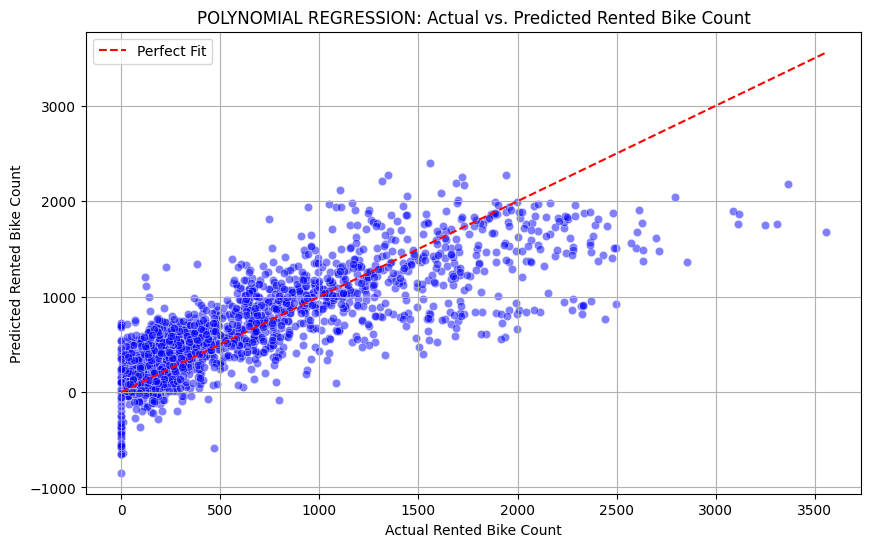

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_p, y=y_pred_poly, alpha=0.5, color='blue')
plt.plot([y_test_p.min(), y_test_p.max()], [y_test_p.min(), y_test_p.max()], 'r--', label='Perfect Fit')
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("POLYNOMIAL REGRESSION: Actual vs. Predicted Rented Bike Count")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
# Polynomial Ridge Regression
alphas_p = np.logspace(-3,1,40)

ridge_cv_p = RidgeCV(alphas=alphas_p, cv=10)
ridge_cv_p.fit(X_train_p, y_train_p)

RidgeCV(alphas=array([1.00000000e-03, 1.26638017e-03, 1.60371874e-03, 2.03091762e-03,
       2.57191381e-03, 3.25702066e-03, 4.12462638e-03, 5.22334507e-03,
       6.61474064e-03, 8.37677640e-03, 1.06081836e-02, 1.34339933e-02,
       1.70125428e-02, 2.15443469e-02, 2.72833338e-02, 3.45510729e-02,
       4.37547938e-02, 5.54102033e-02, 7.01703829e-02, 8.88623816e-02,
       1.12533558e-01, 1.42510267e-01, 1.80472177e-01, 2.28546386e-01,
       2.89426612e-01, 3.66524124e-01, 4.64158883e-01, 5.87801607e-01,
       7.44380301e-01, 9.42668455e-01, 1.19377664e+00, 1.51177507e+00,
       1.91448198e+00, 2.42446202e+00, 3.07029063e+00, 3.88815518e+00,
       4.92388263e+00, 6.23550734e+00, 7.89652287e+00, 1.00000000e+01]),
        cv=10)

In [54]:
ridge_cv_p.alpha_

np.float64(0.004124626382901352)

In [55]:
y_pred_poly_r = ridge_cv_p.predict(X_test_p)

mae_poly_r = mean_absolute_error(y_test_p, y_pred_poly_r)
mse_poly_r = mean_squared_error(y_test_p, y_pred_poly_r)
r2_poly_r = r2_score(y_test_p, y_pred_poly_r)

print("Polynomial Ridge Regression:")
print("Mean Absolute Error:", mae_poly_r)
print("Mean Squared Error:", mse_poly_r)
print("R-squared:", r2_poly_r)

Polynomial Ridge Regression:
Mean Absolute Error: 276.3031680949992
Mean Squared Error: 148270.85619904677
R-squared: 0.6441324971166442


In [56]:
# Polynomial Lasso

lasso_cv_p = LassoCV(alphas=alphas_p, cv=10)
lasso_cv_p.fit(X_train_p, y_train_p)

LassoCV(alphas=array([1.00000000e-03, 1.26638017e-03, 1.60371874e-03, 2.03091762e-03,
       2.57191381e-03, 3.25702066e-03, 4.12462638e-03, 5.22334507e-03,
       6.61474064e-03, 8.37677640e-03, 1.06081836e-02, 1.34339933e-02,
       1.70125428e-02, 2.15443469e-02, 2.72833338e-02, 3.45510729e-02,
       4.37547938e-02, 5.54102033e-02, 7.01703829e-02, 8.88623816e-02,
       1.12533558e-01, 1.42510267e-01, 1.80472177e-01, 2.28546386e-01,
       2.89426612e-01, 3.66524124e-01, 4.64158883e-01, 5.87801607e-01,
       7.44380301e-01, 9.42668455e-01, 1.19377664e+00, 1.51177507e+00,
       1.91448198e+00, 2.42446202e+00, 3.07029063e+00, 3.88815518e+00,
       4.92388263e+00, 6.23550734e+00, 7.89652287e+00, 1.00000000e+01]),
        cv=10)

In [57]:
lasso_cv_p.alpha_

np.float64(0.0032570206556597828)

In [58]:
y_pred_poly_l = lasso_cv_p.predict(X_test_p)

mae_poly_l = mean_absolute_error(y_test_p, y_pred_poly_l)
mse_poly_l = mean_squared_error(y_test_p, y_pred_poly_l)
r2_poly_l = r2_score(y_test_p, y_pred_poly_l)

print("Polynomial Lasso Regression:")
print("Mean Absolute Error:", mae_poly_l)
print("Mean Squared Error:", mse_poly_l)
print("R-squared:", r2_poly_l)

Polynomial Lasso Regression:
Mean Absolute Error: 275.43549406310103
Mean Squared Error: 147660.6271447226
R-squared: 0.6455971186566838


In [59]:
# Polynomial Elastic Net CV
alphas = np.logspace(-2, 2, 100)
l1_ratios = np.linspace(0.01, 1, 100)
elastic_cv_p = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=10)
elastic_cv_p.fit(X_train_p, y_train_p)

ElasticNetCV(alphas=array([1.00000000e-02, 1.09749877e-02, 1.20450354e-02, 1.32194115e-02,
       1.45082878e-02, 1.59228279e-02, 1.74752840e-02, 1.91791026e-02,
       2.10490414e-02, 2.31012970e-02, 2.53536449e-02, 2.78255940e-02,
       3.05385551e-02, 3.35160265e-02, 3.67837977e-02, 4.03701726e-02,
       4.43062146e-02, 4.86260158e-02, 5.33669923e-02, 5.85702082e-02,
       6.42807312e-02, 7.054802...
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ]))

In [60]:
elastic_cv_p.alpha_

np.float64(0.014508287784959394)

In [61]:
elastic_cv_p.l1_ratio_

np.float64(1.0)

In [62]:
y_pred_poly_ecv = elastic_cv_p.predict(X_test_p)

mae_poly_ecv = mean_absolute_error(y_test_p, y_pred_poly_ecv)
mse_poly_ecv = mean_squared_error(y_test_p, y_pred_poly_ecv)
r2_poly_ecv = r2_score(y_test_p, y_pred_poly_ecv)

print("Polynomial ElasticNetCV Regression:")
print("Mean Absolute Error:", mae_poly_ecv)
print("Mean Squared Error:", mse_poly_ecv)
print("R-squared:", r2_poly_ecv)

Polynomial ElasticNetCV Regression:
Mean Absolute Error: 275.3500505957605
Mean Squared Error: 147631.90659616195
R-squared: 0.6456660513529648


In [81]:
# Saving all results
results = pd.DataFrame([
    ["Linear Regression", mae, mse, r2],
    ["Ridge Regression", mae_rt, mse_rt, r2_rt],
    ["Lasso Regression ", mae_la, mse_la, r2_la],
    ["ElasticNet Regression", mae_ecv, mse_ecv, r2_ecv],
    ["Polynomial Regression", mae_poly, mse_poly, r2_poly],
    ["Polynomial Ridge", mae_poly_r, mse_poly_r, r2_poly_r],
    ["Polynomial Lasso", mae_poly_l, mse_poly_l, r2_poly_l],
    ["Polynomial ElasticNet", mae_poly_ecv, mse_poly_ecv, r2_poly_ecv]
], columns=["Model", "MAE", "MSE", "R²"])

results

,Model,MAE,MSE,R²
0,Linear Regression,294.809868,174841.438293,0.580360
1,Ridge Regression,294.489122,174816.807633,0.580419
2,Lasso Regression,294.814749,174847.648853,0.580345
3,ElasticNet Regression,294.721725,174816.614410,0.580420
4,Polynomial Regression,276.537791,148488.320626,0.643611
5,Polynomial Ridge,276.303168,148270.856199,0.644132
6,Polynomial Lasso,275.435494,147660.627145,0.645597
7,Polynomial ElasticNet,275.350051,147631.906596,0.645666


In [65]:
# Save best model

import joblib

joblib.dump(elastic_cv_p, 'best_poly_model.pkl')

['best_poly_model.pkl']

## ----------------------------------------------------------------------------------------------

#  Part 4: Model evaluation and validation

In [70]:
from sklearn.model_selection import cross_val_score

# Do Linear Regression Cross Val

linear_cv = cross_val_score(linear, X_train, y_train, cv=10, scoring='r2')

print("Linear Regression Cross Validation Scores:", linear_cv.round(4))
print("")
print("Standard Deviation Cross Validation Scores:", linear_cv.std().round(4))
print("Mean Linear Regression Cross Validation Score:", linear_cv.mean().round(4))


Linear Regression Cross Validation Scores: [0.5957 0.5531 0.5703 0.6209 0.6052 0.6311 0.6094 0.6037 0.5659 0.6159]

Standard Deviation Cross Validation Scores: 0.0244
Mean Linear Regression Cross Validation Score: 0.5971


In [79]:
# Cross Val on Polynomial lasso

lasso_cv = cross_val_score(lasso_cv_p, X_train_p, y_train_p, cv=10, scoring='r2')

print("Polynomial ElasticNet Cross Validation Scores:", lasso_cv.round(4))
print("")
print("Standard Deviation Cross Validation Scores:", lasso_cv.std().round(4))
print("Mean Polynomial ElasticNet Cross Validation Score:", lasso_cv.mean().round(4))

Polynomial ElasticNet Cross Validation Scores: [0.617  0.629  0.6508 0.7015 0.674  0.6657 0.6808 0.6921 0.6485 0.6768]

Standard Deviation Cross Validation Scores: 0.0257
Mean Polynomial ElasticNet Cross Validation Score: 0.6636


# Analysis of the two models
- Looking at both versions withiout polynomial features and one with those features we can see the differences between the two in terms of performance of predictive capabilities

- For Linear Regression baseline cross validation:
  - Mean R^2: 0.597
  - Std Deviation: 0.0244

- Polynomial Lasso Regression:
  - Mean R^2: 0.6636
  - Std Deviation: 0.0257

- As can be seen, the polynomial features improve upon the baseline linear regression model, even if it is a slight improvement.

- Even looking at the other models, the cross validation score mean of lasso regression is better then the other models by a tiny amount.

# Task 5: Reporting and insights

1. The differnt linear regression models showcased similar results as I trained and tested the different models. The models all have a similar R² ≈ 0.58, which shows that the linear regression somewhat of a fair job parsing the data for predictions
  - but when we introduce polynimial models, the  R² improves to about 0.64.
  this allowed the models to capture nonlinear relationships with the different features of the data.
  - The polynomial Lasso and the ElasticNet models achieved the higher results from the other models, showing they are more stable and achieve higher predictive qualities compared to the other models.

  2. Some of the basic findings we can get from these models is that the predicted bikes rented really depend on the temperature, time of the day, and humidity, among other things. As they interacted, we can find they highly correlate with the bike demand
  - these different findings can help the business to plan accordingly to further optimize bike rentals for high or low demand periods.

  3. To improve our models, we can use higher degrees of polynomial features, as I only used 2 degrees. It takes a lot longer to go through higher degrees, but would allow for better stability and accuracy.
  - Performing feature scaling after train test split next time will also be a good thing to keep in mind.
